<a href="https://colab.research.google.com/github/rahafabumwise/IEEE-AI-Modeling-Hackathon-2.0-Stage-1-Challenge/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Import libraries

In [25]:
from google.colab import drive
import os
import pandas as pd
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor


In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.9 MB/s eta 0:00:00


#2. Load Dataset

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
path = "/content/drive/MyDrive/datasets/ieee-ai-modeling-hackathon2-stage-1-challenge"

In [8]:
train = pd.read_csv(path+"/train.csv")
test = pd.read_csv(path+"/test.csv")

In [9]:
train

,id,sensor_20,humidity,sensor_22,sensor_19,sensor_01,vibration_rms,sensor_24,sensor_07,core_temp,...,chamber_pressure,duty_cycle,sensor_08,sensor_13,sensor_27,coolant_flow,sensor_10,sensor_09,sensor_12,edi
0,0,-0.14829,NaN,1.36691,1.13844,44.58473,0.59021,1.03401,179.87790,66.28937,...,2.18900,0.77936,25.30867,-5.64034,6304.22495,8.87366,164.17897,109.24556,-87.29979,57.5168
1,1,-1.01483,39.74295,-0.44525,-0.55029,0.88831,1.82394,2.59000,40.19866,50.11278,...,1.94912,0.93859,5.59165,10.53628,522.15161,8.30789,-3.58157,93.01212,-102.32777,27.0506
2,2,-0.81559,81.95129,2.05863,-2.54413,21.56722,0.83965,2.57709,93.39048,59.73105,...,4.17573,0.91610,14.68666,1.45935,2339.48544,6.02931,60.35447,101.01501,-100.33441,120.0552
3,3,0.41427,45.97983,4.34967,0.79846,37.43396,0.14636,3.18842,150.78959,61.48525,...,5.98682,0.56353,18.24278,-10.36513,4712.65735,7.39218,129.81099,102.51529,-89.87950,21.1090
4,4,1.17594,57.17967,3.42985,-2.40184,-8.43888,2.12707,3.40071,8.86067,60.96648,...,5.62247,0.71667,-4.23359,3.45261,87.14686,7.74634,-30.76353,87.26374,-104.07413,21.5151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,23995,0.53177,60.49452,-0.18723,0.70229,15.83618,0.89337,1.73046,89.96278,45.02114,...,2.12705,0.44833,14.68548,6.79499,2141.73982,5.18691,59.14429,106.77202,-100.57991,19.0058
23996,23996,-1.31018,57.27616,-0.88924,0.62185,49.70257,0.45453,0.22067,195.82977,48.27757,...,2.95389,0.55135,32.34458,-2.22453,6883.54302,6.97433,181.72669,119.28229,-88.82421,12.7136
23997,23997,0.35943,46.56718,0.03200,-0.39300,44.16641,0.09047,1.74148,175.37424,68.78916,...,4.07463,0.62109,26.97943,-2.29541,5895.27062,6.73040,159.03935,101.46801,-90.77608,234.0302
23998,23998,-0.31410,37.40508,0.63830,-0.37291,175.01163,0.22904,0.45307,598.19931,46.45165,...,2.42011,0.70758,109.09476,-17.15633,36518.97512,NaN,648.64356,174.07925,-55.45499,76.8866


In [10]:
test

,id,sensor_20,humidity,sensor_22,sensor_19,sensor_01,vibration_rms,sensor_24,sensor_07,core_temp,...,hours_since_service,chamber_pressure,duty_cycle,sensor_08,sensor_13,sensor_27,coolant_flow,sensor_10,sensor_09,sensor_12
0,24000,-0.40302,42.60282,2.76838,0.65742,7.47016,0.11738,0.96397,70.02648,62.11087,...,302.62239,3.39008,0.64416,7.74732,6.78274,1352.52072,8.87965,31.93998,95.56604,-107.07532
1,24001,-0.78383,39.21831,4.23730,-3.39030,10.98694,0.85698,4.26710,75.42001,66.90629,...,337.51316,5.91610,0.80678,6.32178,4.73042,1586.65216,6.28518,43.00496,86.38477,-94.93983
2,24002,0.71874,37.92507,0.16000,-1.12425,122.75242,0.21583,1.63227,426.46983,67.06301,...,2027.48003,3.40444,0.29465,71.86401,-13.65901,22238.32248,8.20480,451.56941,141.28029,-66.77507
3,24003,1.03094,50.81091,-1.55951,-2.56725,6.13757,1.74156,2.20116,49.17950,67.78357,...,220.00147,3.83001,0.98778,-0.42742,2.42208,844.86458,8.04383,9.62493,85.79741,-100.05217
4,24004,-0.50860,22.57288,0.01894,-2.09840,0.08979,0.90965,1.20775,41.10542,54.35825,...,165.19041,4.09906,0.93110,2.09651,9.75572,552.98369,7.69060,3.33153,88.70382,-106.33311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,39995,-0.27649,69.71687,-4.52670,-0.35153,2.01290,0.09465,3.84929,41.09987,60.47523,...,NaN,3.82408,0.25209,4.89273,4.84604,663.62908,8.31462,2.09776,94.21337,-104.24440
15996,39996,-0.83593,NaN,2.46156,-0.10112,18.67415,0.83798,3.32832,107.92773,63.41473,...,503.79675,4.91732,0.38671,14.79540,3.57766,2861.48678,NaN,79.79987,99.32887,-98.41122
15997,39997,-0.22683,66.20245,-2.67764,1.22501,-3.62488,0.48924,1.18228,11.36076,72.43525,...,47.94649,1.60705,0.26610,-4.84692,4.40125,90.51522,8.35666,-34.77972,82.24418,-108.63549
15998,39998,0.22098,40.30300,-1.46787,2.04262,27.42173,0.18471,2.71102,120.38724,70.51275,...,558.72750,5.24482,0.73260,16.06269,-1.63450,3332.76321,13.27331,95.46439,92.12338,-95.48275


#3. Data Exploration

In [12]:
train.isna().sum()

,0
id,0
sensor_20,0
humidity,1894
sensor_22,0
sensor_19,0
sensor_01,0
vibration_rms,1152
sensor_24,0
sensor_07,0
core_temp,0


In [13]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (24000, 44)
Test shape: (16000, 43)


<Axes: >

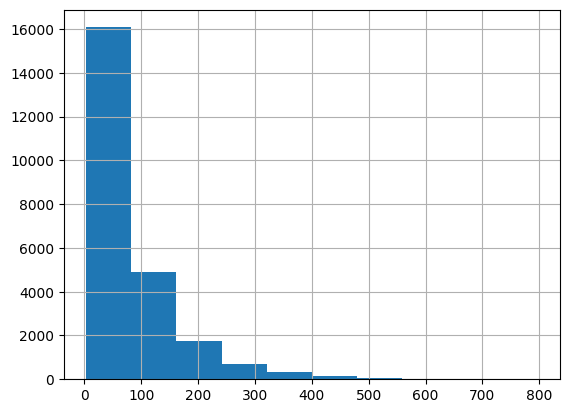

In [16]:
train["edi"].hist()

In [17]:
train.columns.tolist()

['id',
 'sensor_20',
 'humidity',
 'sensor_22',
 'sensor_19',
 'sensor_01',
 'vibration_rms',
 'sensor_24',
 'sensor_07',
 'core_temp',
 'sensor_17',
 'sensor_15',
 'sensor_02',
 'sensor_11',
 'sensor_14',
 'sensor_26',
 'delta_ambient',
 'sensor_03',
 'phase_imbalance',
 'sensor_23',
 'asset_age',
 'grid_freq',
 'sensor_25',
 'sensor_18',
 'harmonic_thd',
 'sensor_21',
 'sensor_05',
 'load_factor',
 'sensor_16',
 'sensor_04',
 'line_voltage',
 'sensor_06',
 'sensor_28',
 'hours_since_service',
 'chamber_pressure',
 'duty_cycle',
 'sensor_08',
 'sensor_13',
 'sensor_27',
 'coolant_flow',
 'sensor_10',
 'sensor_09',
 'sensor_12',
 'edi']

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   24000 non-null  int64  
 1   sensor_20            24000 non-null  float64
 2   humidity             22106 non-null  float64
 3   sensor_22            24000 non-null  float64
 4   sensor_19            24000 non-null  float64
 5   sensor_01            24000 non-null  float64
 6   vibration_rms        22848 non-null  float64
 7   sensor_24            24000 non-null  float64
 8   sensor_07            24000 non-null  float64
 9   core_temp            24000 non-null  float64
 10  sensor_17            22087 non-null  float64
 11  sensor_15            24000 non-null  float64
 12  sensor_02            24000 non-null  float64
 13  sensor_11            24000 non-null  float64
 14  sensor_14            24000 non-null  float64
 15  sensor_26            24000 non-null 

In [19]:
missing = train.isnull().sum()

print(missing[missing > 0])

humidity               1894
vibration_rms          1152
sensor_17              1913
sensor_05               910
hours_since_service     869
coolant_flow           1392
dtype: int64


In [23]:

# --------------------------------------------------
# 2. Separate features and target
# --------------------------------------------------

# Remove id because it is only an identifier.
# Remove edi because it is the value we want to predict.
X = train.drop(columns=["id", "edi"])

y = train["edi"]

print("Number of features:", X.shape[1])


# --------------------------------------------------
# 3. Split train data into training and validation
# --------------------------------------------------

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])


# --------------------------------------------------
# 4. Transform the target
# --------------------------------------------------

y_train_log = np.log1p(y_train)


# --------------------------------------------------
# 5. Create the XGBoost model
# --------------------------------------------------

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


# --------------------------------------------------
# 6. Train the model
# --------------------------------------------------

model.fit(X_train, y_train_log)


# --------------------------------------------------
# 7. Predict the validation data
# --------------------------------------------------

valid_predictions_log = model.predict(X_valid)

# Convert predictions from log scale back to EDI scale.
valid_predictions = np.expm1(valid_predictions_log)

# RMSLE cannot accept negative predictions.
valid_predictions = np.clip(valid_predictions, 0, None)


# --------------------------------------------------
# 8. Calculate RMSLE
# --------------------------------------------------

rmsle = np.sqrt(
    mean_squared_log_error(
        y_valid,
        valid_predictions
    )
)

print("XGBoost validation RMSLE:", rmsle)

Number of features: 42
Training rows: 19200
Validation rows: 4800
XGBoost validation RMSLE: 0.20886186085988154


In [24]:
comparison = pd.DataFrame({
    "actual_edi": y_valid.values,
    "predicted_edi": valid_predictions
})

print(comparison.head(10))

   actual_edi  predicted_edi
0     21.4583      23.662766
1     34.3800      34.539570
2     27.9078      28.055918
3    132.3263     125.047997
4     13.2861      14.698544
5     94.7942      74.471405
6    104.3703      83.197403
7    112.2580     132.780594
8     42.5693      29.830198
9     73.2373      66.679489
